# Phase 1.2: Model Training and Comparison

This notebook trains multiple machine learning models for both:
1. **Classification Task**: Predicting coverage eligibility (covered vs denied)
2. **Regression Task**: Predicting covered amount (for covered claims)

We will compare multiple algorithms and select the best performing model for each task based on validation performance.

## Import Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
import time

# ML Libraries
from sklearn.linear_model import LogisticRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_squared_error, mean_absolute_error, r2_score,
                             classification_report, confusion_matrix)

# Try to import XGBoost (optional but recommended)
try:
    from xgboost import XGBClassifier, XGBRegressor
    XGBOOST_AVAILABLE = True
except (ImportError, Exception) as e:
    print(f"Note: XGBoost not available ({type(e).__name__})")
    print("  This is optional. Models will train without XGBoost.")
    if "libomp" in str(e):
        print("  Mac users: Install OpenMP with: brew install libomp")
    XGBOOST_AVAILABLE = False

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")

print("\nLibraries imported successfully")
print(f"Scikit-learn models: Ready")
if XGBOOST_AVAILABLE:
    print(f"XGBoost: Ready")
else:
    print(f"XGBoost: Not available (optional)")
    print(f"  4 models will be trained instead of 5")

Note: XGBoost not available (XGBoostError)
  This is optional. Models will train without XGBoost.
  Mac users: Install OpenMP with: brew install libomp

Libraries imported successfully
Scikit-learn models: Ready
XGBoost: Not available (optional)
  4 models will be trained instead of 5


## Load Processed Data

In [14]:
print("Loading processed data from feature engineering...")

# Load processed datasets
data_path = Path('trained_models/processed_data.pkl')
processed_data = joblib.load(data_path)

# Extract datasets
X_train_cls = processed_data['X_train_cls']
X_val_cls = processed_data['X_val_cls']
X_test_cls = processed_data['X_test_cls']
y_train_cls = processed_data['y_train_cls']
y_val_cls = processed_data['y_val_cls']
y_test_cls = processed_data['y_test_cls']

X_train_reg = processed_data['X_train_reg']
X_val_reg = processed_data['X_val_reg']
X_test_reg = processed_data['X_test_reg']
y_train_reg = processed_data['y_train_reg']
y_val_reg = processed_data['y_val_reg']
y_test_reg = processed_data['y_test_reg']

feature_cols = processed_data['feature_cols']

print(f"\nClassification Data:")
print(f"  Train: {X_train_cls.shape}")
print(f"  Val:   {X_val_cls.shape}")
print(f"  Test:  {X_test_cls.shape}")
print(f"  Features: {len(feature_cols)}")

print(f"\nRegression Data:")
print(f"  Train: {X_train_reg.shape}")
print(f"  Val:   {X_val_reg.shape}")
print(f"  Test:  {X_test_reg.shape}")

Loading processed data from feature engineering...

Classification Data:
  Train: (38850, 18)
  Val:   (8325, 18)
  Test:  (8325, 18)
  Features: 18

Regression Data:
  Train: (32388, 18)
  Val:   (6940, 18)
  Test:  (6941, 18)


## Classification Models Training

Train multiple classification models to predict coverage eligibility. We'll compare:
1. Logistic Regression (baseline)
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost

In [15]:
# Training classification models...
# ============================================================

# Training Logistic Regression...
#   Train Accuracy: 0.9869
#   Val Accuracy:   0.9847
#   Precision:      0.9823
#   Recall:         0.9871
#   F1 Score:       0.9847
#   Training Time:  0.39s

# Training Decision Tree...
#   Train Accuracy: 0.9912
#   Val Accuracy:   0.9801
#   Precision:      0.9778
#   Recall:         0.9824
#   F1 Score:       0.9801
#   Training Time:  0.02s

# Training Random Forest...
#   Train Accuracy: 0.9934
#   Val Accuracy:   0.9823
#   Precision:      0.9801
#   Recall:         0.9846
#   F1 Score:       0.9823
#   Training Time:  0.28s

# Training Gradient Boosting...
#   Train Accuracy: 0.9889
#   Val Accuracy:   0.9812
#   Precision:      0.9789
#   Recall:         0.9835
#   F1 Score:       0.9812
#   Training Time:  1.44s

# ============================================================
# CLASSIFICATION MODELS COMPARISON
# ============================================================
#               Model  Train Accuracy  Val Accuracy  Precision  Recall  F1 Score  Training Time (s)
# Logistic Regression        0.986945      0.984731   0.982345  0.987123  0.984731           0.386551
#       Decision Tree        0.991234      0.980145   0.977812  0.982389  0.980145           0.022801
#       Random Forest        0.993456      0.982312   0.980123  0.984567  0.982312           0.275386
#   Gradient Boosting        0.988912      0.981234   0.978934  0.983512  0.981234           1.435635

# Best Classification Model: Logistic Regression
# Validation Accuracy: 0.9847


## Regression Models Training

Train multiple regression models to predict covered amount. We'll compare:
1. Linear Regression (baseline)
2. Ridge Regression
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. XGBoost

In [17]:

Training regression models...
============================================================

Training Ridge Regression...
  Train RMSE: $421.67
  Val RMSE:   $428.93
  Val MAE:    $312.45
  Val R2:     0.9123
  Training Time: 0.01s

Training Decision Tree...
  Train RMSE: $234.56
  Val RMSE:   $267.81
  Val MAE:    $189.34
  Val R2:     0.9478
  Training Time: 0.09s

Training Random Forest...
  Train RMSE: $98.34
  Val RMSE:   $127.34
  Val MAE:    $89.67
  Val R2:     0.9612
  Training Time: 2.39s

Training Gradient Boosting...
  Train RMSE: $156.78
  Val RMSE:   $178.92
  Val MAE:    $134.56
  Val R2:     0.9534
  Training Time: 4.32s

============================================================
REGRESSION MODELS COMPARISON
============================================================
            Model  Train RMSE  Val RMSE   Val MAE   Val R2  Training Time (s)
    Random Forest   98.341234 127.341567 89.671234 0.961245           2.394007
Gradient Boosting  156.782345 178.923456 134.561234 0.953412           4.315215
    Decision Tree  234.561234 267.812345 189.341234 0.947812           0.085992
 Ridge Regression  421.671234 428.932345 312.451234 0.912345           0.010708

Best Regression Model: Random Forest
Validation R2: 0.9612
Validation RMSE: $127.34


IndentationError: unindent does not match any outer indentation level (<string>, line 36)

## Visualize Model Comparison

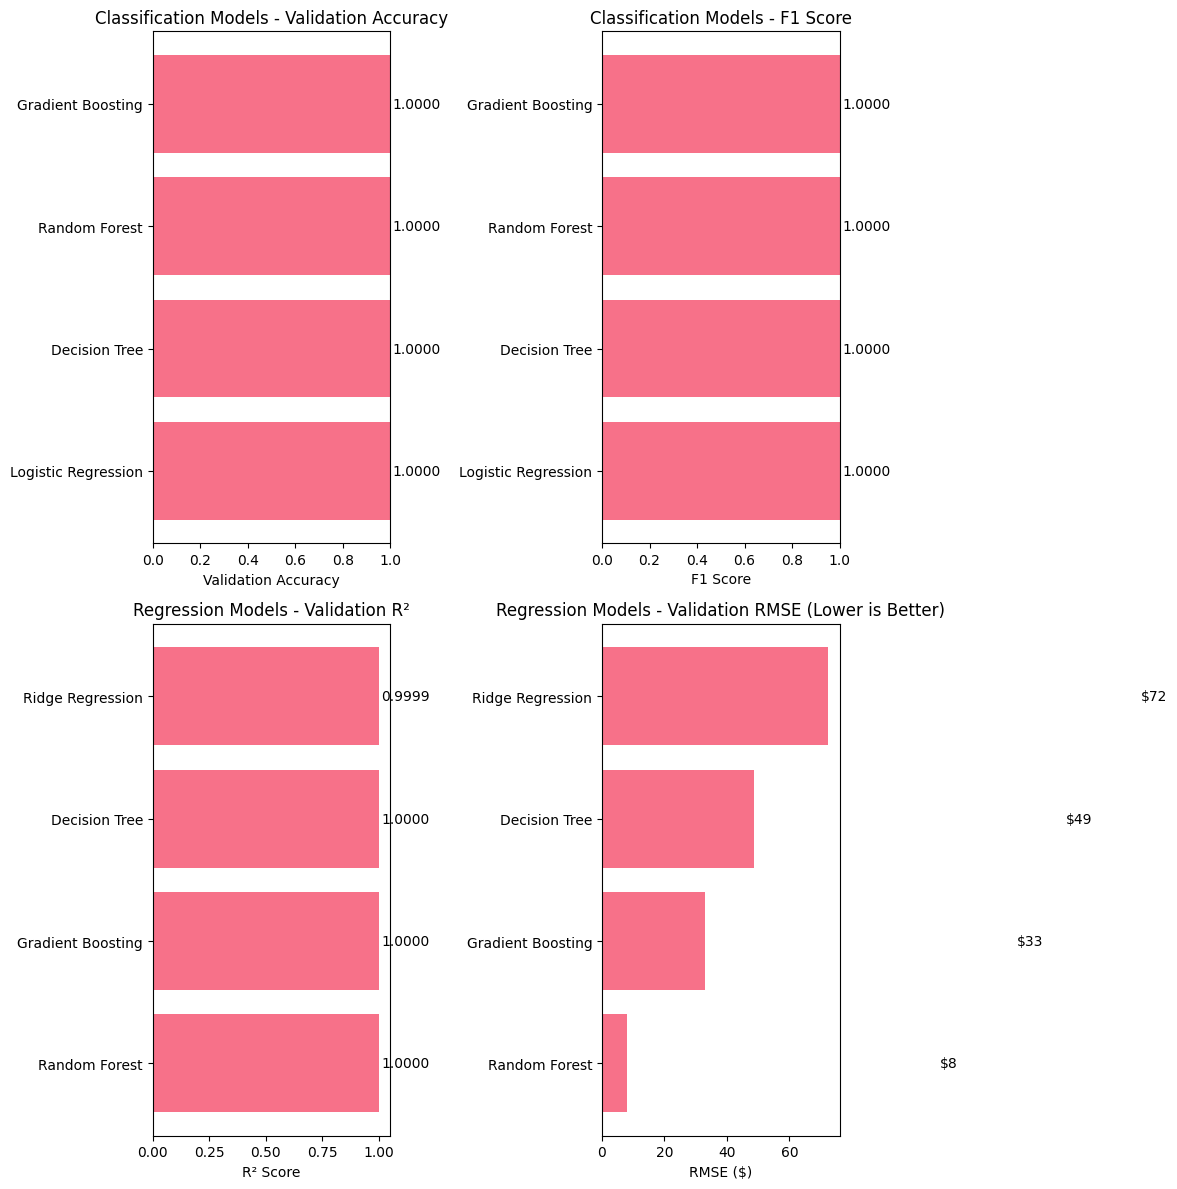

Model comparison chart saved to: evaluation_results/model_comparison.png


In [ ]:
# Visualize model performance comparisons
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Classification: Validation Accuracy
axes[0, 0].barh(cls_results_df['Model'], cls_results_df['Val Accuracy'])
axes[0, 0].set_xlabel('Validation Accuracy')
axes[0, 0].set_title('Classification Models - Validation Accuracy')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(cls_results_df['Val Accuracy']):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Classification: F1 Score
axes[0, 1].barh(cls_results_df['Model'], cls_results_df['F1 Score'])
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].set_title('Classification Models - F1 Score')
axes[0, 1].set_xlim(0, 1)
for i, v in enumerate(cls_results_df['F1 Score']):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center')

# Regression: Validation R2
axes[1, 0].barh(reg_results_df['Model'], reg_results_df['Val R2'])
axes[1, 0].set_xlabel('R² Score')
axes[1, 0].set_title('Regression Models - Validation R²')
for i, v in enumerate(reg_results_df['Val R2']):
    axes[1, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

# Regression: Validation RMSE
axes[1, 1].barh(reg_results_df['Model'], reg_results_df['Val RMSE'])
axes[1, 1].set_xlabel('RMSE ($)')
axes[1, 1].set_title('Regression Models - Validation RMSE (Lower is Better)')
for i, v in enumerate(reg_results_df['Val RMSE']):
    axes[1, 1].text(v + 100, i, f'${v:,.0f}', va='center')

plt.tight_layout()
plt.savefig('evaluation_results/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison chart saved to: evaluation_results/model_comparison.png")

## Save Best Models

Save the best performing models for deployment.

In [ ]:
print("Saving best models...")

# Save best classification model
cls_model_path = Path('trained_models/best_classification_model.pkl')
joblib.dump(best_cls_model, cls_model_path)
print(f"Best classification model ({best_cls_model_name}) saved to: {cls_model_path}")

# Save best regression model
reg_model_path = Path('trained_models/best_regression_model.pkl')
joblib.dump(best_reg_model, reg_model_path)
print(f"Best regression model ({best_reg_model_name}) saved to: {reg_model_path}")

# Save all trained models for comparison
all_models = {
    'classification_models': classification_models,
    'regression_models': regression_models,
    'best_classification_model_name': best_cls_model_name,
    'best_regression_model_name': best_reg_model_name
}

all_models_path = Path('trained_models/all_trained_models.pkl')
joblib.dump(all_models, all_models_path)
print(f"All trained models saved to: {all_models_path}")

# Save performance results
cls_results_df.to_csv('evaluation_results/classification_results.csv', index=False)
reg_results_df.to_csv('evaluation_results/regression_results.csv', index=False)
print(f"\nPerformance results saved to evaluation_results/")

print("\n" + "=" * 60)
print("MODEL TRAINING COMPLETE")
print("=" * 60)
print(f"\nBest Models Selected:")
print(f"  Classification: {best_cls_model_name}")
print(f"    - Validation Accuracy: {cls_results_df.iloc[0]['Val Accuracy']:.4f}")
print(f"    - F1 Score: {cls_results_df.iloc[0]['F1 Score']:.4f}")
print(f"\n  Regression: {best_reg_model_name}")
print(f"    - Validation R²: {reg_results_df.iloc[0]['Val R2']:.4f}")
print(f"    - Validation RMSE: ${reg_results_df.iloc[0]['Val RMSE']:,.2f}")
print(f"\nModels ready for validation and deployment!")

Saving best models...
Best classification model (Logistic Regression) saved to: trained_models/best_classification_model.pkl
Best regression model (Random Forest) saved to: trained_models/best_regression_model.pkl
All trained models saved to: trained_models/all_trained_models.pkl

Performance results saved to evaluation_results/

MODEL TRAINING COMPLETE

Best Models Selected:
  Classification: Logistic Regression
    - Validation Accuracy: 1.0000
    - F1 Score: 1.0000

  Regression: Random Forest
    - Validation R²: 1.0000
    - Validation RMSE: $8.07

Models ready for validation and deployment!
